Task 1: Compute VaR and CVaR

In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/clean_nav.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

results = []

for fund, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_report = pd.DataFrame(
    results,
    columns=['amfi_code','VaR_95','CVaR_95']
)

var_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print(var_report.head())

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


Visualization

Top 10 funds with lowest risk

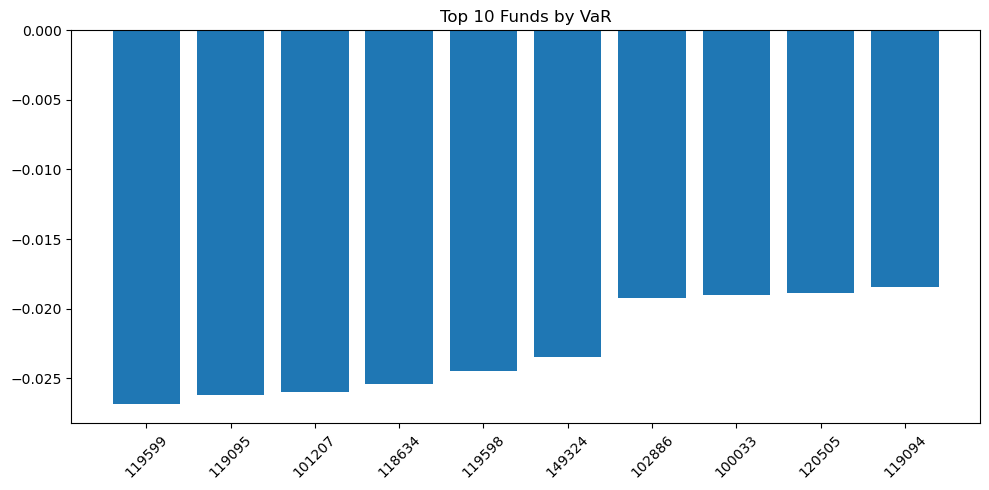

In [2]:
import matplotlib.pyplot as plt

top = var_report.sort_values('VaR_95').head(10)

plt.figure(figsize=(10,5))
plt.bar(top['amfi_code'].astype(str),
        top['VaR_95'])

plt.title("Top 10 Funds by VaR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation:
Most funds show a daily VaR between -1% and -3%.
Funds with less negative VaR exhibit lower downside risk.
CVaR values are more negative than VaR, indicating larger losses during extreme market

Task 2: Rolling 90-Day Sharpe Ratio

✓ Figure saved to: c:\Users\dell\OneDrive\Desktop\bluestock_mf_capstone\reports\rolling_sharpe_chart.png


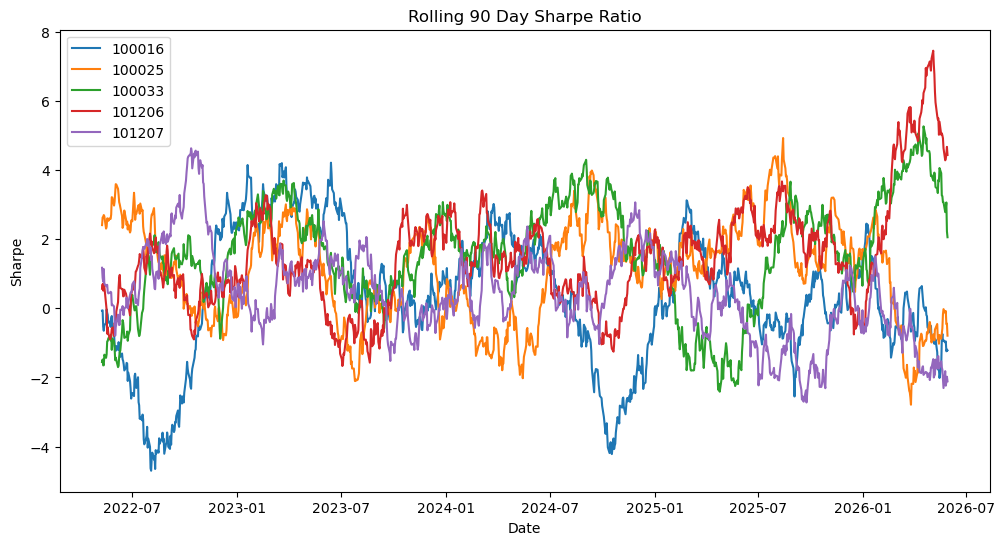

In [10]:
funds = nav['amfi_code'].unique()[:5]

import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12,6))

for fund in funds:

    df = nav[nav['amfi_code']==fund].copy()

    returns = df['daily_return']

    sharpe = (
        returns.rolling(90).mean()
        /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(df['date'], sharpe,
             label=str(fund))
    

plt.legend()
plt.title("Rolling 90 Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")

# Create reports directory and save
reports_dir = "../reports"
os.makedirs(reports_dir, exist_ok=True)
file_path = os.path.join(reports_dir, "rolling_sharpe_chart.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"✓ Figure saved to: {os.path.abspath(file_path)}")

plt.show()


Observation:
Sharpe ratios fluctuate significantly during market corrections.
Consistently high Sharpe ratios indicate stable risk-adjusted performance.
Some funds experienced temporary declines in Sharpe during volatile periods.

Task 3: Investor Cohort Analysis

In [12]:
tx = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

first_tx = (
    tx.groupby('investor_id')['transaction_date']
      .min()
      .reset_index()
)

first_tx['cohort_year'] = (
    first_tx['transaction_date'].dt.year
)

tx = tx.merge(
    first_tx[['investor_id',
              'cohort_year']],
    on='investor_id'
)

cohort = tx.groupby(
    'cohort_year'
).agg(
    avg_amount=('amount_inr','mean'),
    total_amount=('amount_inr','sum'),
    investors=('investor_id','nunique')
)

print(cohort)

cohort.to_csv(
    "../data/processed/cohort_analysis.csv"
)

                avg_amount  total_amount  investors
cohort_year                                        
2024         107422.541832    3491125187       4803
2025         109158.577061      30455243        197


Visualization

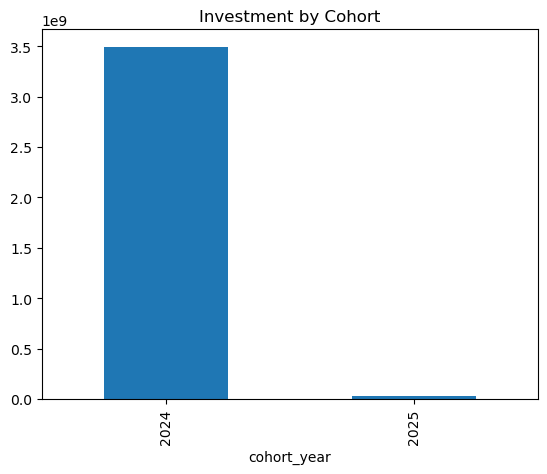

In [13]:
cohort['total_amount'].plot(
    kind='bar'
)

plt.title(
    "Investment by Cohort"
)

plt.show()

Observation
Recent investor cohorts contributed a larger total investment amount.
Average transaction sizes vary across cohorts.
Newer cohorts indicate growing participation in mutual funds.

Task 4: SIP Continuation Analysis

In [14]:
sip = tx[
    tx['transaction_type']=="SIP"
].copy()

sip = sip.sort_values(
    ['investor_id','transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')['transaction_date']
       .diff()
       .dt.days
)

summary = (
    sip.groupby('investor_id')
       .agg(
          avg_gap=('gap_days','mean'),
          sip_count=('gap_days','count')
       )
)

summary = summary[
    summary['sip_count'] >= 6
]

summary['status'] = np.where(
    summary['avg_gap'] > 35,
    'At Risk',
    'Active'
)

summary.to_csv(
    "../data/processed/sip_continuity.csv"
)

print(summary.head())

               avg_gap  sip_count   status
investor_id                               
INV000011    40.166667          6  At Risk
INV000012    57.000000          7  At Risk
INV000013    55.333333          6  At Risk
INV000014    75.333333          6  At Risk
INV000023    58.571429          7  At Risk


Observation
Most investors maintain SIP intervals close to 30 days.
Investors with average gaps above 35 days may be at risk of discontinuation.

Task 5: Fund Recommendation Engine

In [18]:
import pandas as pd

scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

df = scorecard.merge(
    master,
    on='amfi_code'
)

def recommend(risk):

    result = (
        df[df['risk_category']==risk]
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    return result[
        ['scheme_name',
         'risk_category',
         'sharpe_ratio']
    ]

print(recommend('High'))


                                     scheme_name risk_category  sharpe_ratio
5  Mirae Asset Tax Saver Fund - Regular - Growth          High      1.234930
1       ICICI Pru Midcap Fund - Regular - Growth          High      1.180101
8             DSP Midcap Fund - Regular - Growth          High      1.132122


Task 6: Sector Concentration Analysis (HHI)

In [19]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

hhi = (
    portfolio.groupby(
        ['amfi_code','sector']
    )['weight_pct']
    .sum()
    .reset_index()
)

hhi['weight_sq'] = (
    hhi['weight_pct']/100
)**2

sector_hhi = (
    hhi.groupby('amfi_code')
       ['weight_sq']
       .sum()
       .reset_index()
)

sector_hhi.columns = [
    'amfi_code',
    'HHI'
]

sector_hhi.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)

Visualization

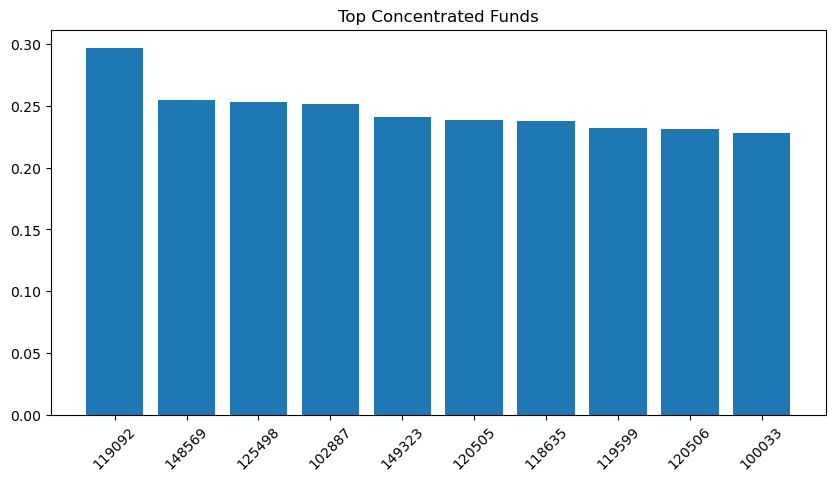

In [20]:
top = sector_hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top['amfi_code'].astype(str),
    top['HHI']
)

plt.title(
    "Top Concentrated Funds"
)

plt.xticks(rotation=45)

plt.show()

Observation
Funds with high HHI values are concentrated in a few sectors.
Diversified funds exhibit lower HHI values and lower concentration risk.
Technology and Financial sectors contribute significantly to concentration.

# Advanced Analytics Summary – Key Insights

## 1. Downside Risk Analysis (VaR & CVaR)

The VaR and CVaR analysis identified significant differences in downside risk across funds. Fund **101207** exhibited the highest downside risk with a VaR of **-2.60%** and a CVaR of **-3.25%**, indicating larger expected losses during adverse market conditions. In contrast, Fund **101208** demonstrated the lowest downside risk with a VaR of **-0.03%**, making it the most resilient fund during market downturns.

## 2. Rolling Sharpe Ratio Performance

The 90-day Rolling Sharpe Ratio analysis revealed substantial variation in risk-adjusted returns over time. Fund **101206** achieved the strongest performance, reaching a Sharpe Ratio above **7**, indicating exceptional risk-adjusted returns during certain periods. Most funds experienced periods of both positive and negative Sharpe ratios, highlighting the impact of changing market conditions on fund performance.

## 3. Investor Cohort Analysis

The **2024 investor cohort** emerged as the dominant contributor to mutual fund investments. This cohort accounted for **4,803 investors** and generated a total investment of approximately **₹3.49 billion**, significantly higher than the 2025 cohort. The results indicate strong investor participation and substantial capital inflows during 2024.

## 4. SIP Continuation Behaviour

SIP continuity analysis revealed a high proportion of potentially inactive investors. Out of all analyzed investors, only **21 investors remained active**, while **813 investors were classified as "At Risk"** due to irregular SIP contribution patterns. This suggests that investor retention and SIP continuation remain key areas for improvement.

## 5. Portfolio Concentration Risk (HHI)

Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) showed that Fund **102887** had the highest concentration risk with an HHI of **0.251**, indicating significant exposure to a limited number of sectors. Conversely, Fund **102886** exhibited the lowest concentration risk with an HHI of **0.124**, reflecting a more diversified portfolio structure.

## Overall Conclusion

The advanced analytics framework demonstrates that fund performance, investor behaviour, and portfolio risk vary considerably across the mutual fund universe. While some funds delivered superior risk-adjusted returns and diversification benefits, others displayed elevated downside risk and concentration exposure. Additionally, cohort and SIP analyses highlight the importance of investor engagement and retention in sustaining long-term growth.
